<a href="https://colab.research.google.com/github/Jee8825/AMD-Slingshot-MVP/blob/main/Day_4/Day_4_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install pyspark

In [6]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year,month,to_date,col,round as spark_round
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [7]:
spark = SparkSession.builder \
    .appName('DAY4_BigData_Sales') \
    .config('spark.some.config.option', 'some-value') \
    .getOrCreate()

In [8]:
df = spark.read.csv('/content/large sales dataset.csv', header=True, inferSchema=True)
df.show(5)
df.printSchema()

+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|   product|   category|quantity|unit_price|revenue|order_date|     city|region|  sales_rep|  payment_method|order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|    1001|  Sneha Reddy|   Monitor|Electronics|      12|     22000| 264000|2023-05-21|   Mumbai|  West|Meera Patel|             UPI|   Delivered|
|    1002| Ramesh Kumar|   Printer|Electronics|      10|     12000| 120000|2023-08-05|    Delhi| North|Anil Sharma|     Credit Card|     Shipped|
|    1003| Rahul Mishra|     Mouse|Accessories|      10|       800|   8000|2023-01-14|Ahmedabad|  West|Meera Patel|Cash on Delivery|     Shipped|
|    1004|   Suresh Rao|    Tablet|Electronics|       5|     32000| 160000|2023-01-04|    Surat|  West| Ravi Kumar|Cash on D

In [9]:
print(f"{spark.version}")

4.0.2


In [10]:
df_bronze=spark.read \
    .option("header","true") \
    .option("inferSchema","true") \
    .csv("/content/large sales dataset.csv")
print(f'Bronze table row count: {df_bronze.count()}')
print(f'Bronze table column count: {len(df_bronze.columns)}')

Bronze table row count: 5000
Bronze table column count: 13


In [11]:
df_bronze.select('quantity','unit_price','revenue').describe().show()

+-------+-----------------+------------------+------------------+
|summary|         quantity|        unit_price|           revenue|
+-------+-----------------+------------------+------------------+
|  count|             5000|              5000|              5000|
|   mean|           7.9536|          12496.86|          99169.52|
| stddev|4.275313169878912|14857.384309295603|145972.97195261103|
|    min|                1|               600|               600|
|    max|               15|             45000|            675000|
+-------+-----------------+------------------+------------------+



In [12]:
df_bronze.write \
    .mode('overwrite') \
    .parquet('sales_bronze.parquet')

In [13]:
from pyarrow.ipc import pa
import os

def get_dir_size(path):
  if os.path.isfile(path):
    return os.path.getsize(path)/1024
  for dirpath, dirnames, filenames in os.walk(path):
    return sum(get_dir_size(os.path.join(dirpath, name)) for name in filenames)/1024
csv_size = get_dir_size('/content/large sales dataset.csv')
parquet_size = get_dir_size('/content/sales_bronze.parquet')
reduction=(1-parquet_size/csv_size)*100
print(f'csv_size: {csv_size} KB')
print(f'parquet_size: {parquet_size} KB')
print(f'reduction: {reduction}')

csv_size: 529.3125 KB
parquet_size: 0.053806304931640625 KB
reduction: 99.98983468084892


In [14]:
from pyspark.sql.functions import col

df_bronze = df_bronze.withColumn("calculated_quantity", col("revenue") / col("unit_price"))

df_bronze.select("unit_price", "revenue", "calculated_quantity", "quantity").show(5)

+----------+-------+-------------------+--------+
|unit_price|revenue|calculated_quantity|quantity|
+----------+-------+-------------------+--------+
|     22000| 264000|               12.0|      12|
|     12000| 120000|               10.0|      10|
|       800|   8000|               10.0|      10|
|     32000| 160000|                5.0|       5|
|      3500|  14000|                4.0|       4|
+----------+-------+-------------------+--------+
only showing top 5 rows


In [15]:
df_high_revenue = df_bronze.filter(col("revenue") > 100000).show(10)

+--------+-------------+-------+-----------+--------+----------+-------+----------+---------+------+------------+----------------+------------+-------------------+
|order_id|customer_name|product|   category|quantity|unit_price|revenue|order_date|     city|region|   sales_rep|  payment_method|order_status|calculated_quantity|
+--------+-------------+-------+-----------+--------+----------+-------+----------+---------+------+------------+----------------+------------+-------------------+
|    1001|  Sneha Reddy|Monitor|Electronics|      12|     22000| 264000|2023-05-21|   Mumbai|  West| Meera Patel|             UPI|   Delivered|               12.0|
|    1002| Ramesh Kumar|Printer|Electronics|      10|     12000| 120000|2023-08-05|    Delhi| North| Anil Sharma|     Credit Card|     Shipped|               10.0|
|    1004|   Suresh Rao| Tablet|Electronics|       5|     32000| 160000|2023-01-04|    Surat|  West|  Ravi Kumar|Cash on Delivery|  Processing|                5.0|
|    1008|  Priy

In [16]:
df_sliver=df_bronze \
    .dropDuplicates() \
    .dropna(subset=['quantity','unit_price','revenue'])
df_sliver=df_sliver.withColumn("order_date",to_date(col("order_date"),"yyyy-MM-dd")) \
    .withColumn("year",year(col("order_date"))) \
    .withColumn("month",month(col("order_date")))
df_sliver=df_sliver.withColumn("revenue_category",F.when(col('revenue')>40000,'High')\
                                        .when((col('revenue')>10000) & (col('revenue')<=40000),'Medium')\
                                        .otherwise('Low'))
df_sliver.show(5)
print(f'Sliver table row count: {df_sliver.count()}')
print(f'Sliver table column count: {len(df_sliver.columns)}')

+--------+-------------+-------+-----------+--------+----------+-------+----------+---------+------+------------+--------------+------------+-------------------+----+-----+----------------+
|order_id|customer_name|product|   category|quantity|unit_price|revenue|order_date|     city|region|   sales_rep|payment_method|order_status|calculated_quantity|year|month|revenue_category|
+--------+-------------+-------+-----------+--------+----------+-------+----------+---------+------+------------+--------------+------------+-------------------+----+-----+----------------+
|    1019|Kavya Nambiar|Printer|Electronics|       9|     12000| 108000|2023-02-24|Bangalore| South|Deepak Joshi|           UPI|     Shipped|                9.0|2023|    2|            High|
|    1454|  Sneha Reddy|Speaker|Electronics|       3|      4500|  13500|2023-10-16|    Surat|  West| Kavya Reddy|   Net Banking|     Shipped|                3.0|2023|   10|          Medium|
|    1608|  Meera Joshi| Tablet|Electronics|      

In [17]:
df_sliver.write \
    .mode('overwrite') \
    .parquet('sales_sliver.parquet')
df_verify=spark.read.parquet('/content/sales_sliver.parquet')
df_verify.show(5)
df_verify.printSchema()

+--------+-------------+-------+-----------+--------+----------+-------+----------+---------+------+------------+--------------+------------+-------------------+----+-----+----------------+
|order_id|customer_name|product|   category|quantity|unit_price|revenue|order_date|     city|region|   sales_rep|payment_method|order_status|calculated_quantity|year|month|revenue_category|
+--------+-------------+-------+-----------+--------+----------+-------+----------+---------+------+------------+--------------+------------+-------------------+----+-----+----------------+
|    1019|Kavya Nambiar|Printer|Electronics|       9|     12000| 108000|2023-02-24|Bangalore| South|Deepak Joshi|           UPI|     Shipped|                9.0|2023|    2|            High|
|    1454|  Sneha Reddy|Speaker|Electronics|       3|      4500|  13500|2023-10-16|    Surat|  West| Kavya Reddy|   Net Banking|     Shipped|                3.0|2023|   10|          Medium|
|    1608|  Meera Joshi| Tablet|Electronics|      

In [18]:
print(f'Bronze Size: {get_dir_size("/content/sales_bronze.parquet")} KB')
print(f'Sliver Size: {get_dir_size("/content/sales_sliver.parquet")} KB')

Bronze Size: 0.053806304931640625 KB
Sliver Size: 0.061188697814941406 KB


In [19]:
df_sliver.groupBy('product').agg(F.sum('revenue').alias('total_revenue')).orderBy(F.desc('total_revenue')).limit(5).show()

+-------+-------------+
|product|total_revenue|
+-------+-------------+
| Laptop|    182700000|
| Tablet|    135104000|
|Monitor|     82126000|
|Printer|     44544000|
|Speaker|     16317000|
+-------+-------------+



In [20]:
print('Top 5 products by total revenue (Ascending order):')
df_sliver.groupBy('product').agg(F.sum('revenue').alias('total_revenue')).orderBy(F.asc('total_revenue')).limit(5).show()

print('\nTop 5 products by total revenue (Descending order):')
df_sliver.groupBy('product').agg(F.sum('revenue').alias('total_revenue')).orderBy(F.desc('total_revenue')).limit(5).show()

print('\nTop 10 products by total revenue (Descending order):')
df_sliver.groupBy('product').agg(F.sum('revenue').alias('total_revenue')).orderBy(F.desc('total_revenue')).limit(10).show()

Top 5 products by total revenue (Ascending order):
+----------+-------------+
|   product|total_revenue|
+----------+-------------+
|   USB Hub|      2447400|
|     Mouse|      3207200|
|  Keyboard|      4878000|
|    Webcam|     10982500|
|Headphones|     13541500|
+----------+-------------+


Top 5 products by total revenue (Descending order):
+-------+-------------+
|product|total_revenue|
+-------+-------------+
| Laptop|    182700000|
| Tablet|    135104000|
|Monitor|     82126000|
|Printer|     44544000|
|Speaker|     16317000|
+-------+-------------+


Top 10 products by total revenue (Descending order):
+----------+-------------+
|   product|total_revenue|
+----------+-------------+
|    Laptop|    182700000|
|    Tablet|    135104000|
|   Monitor|     82126000|
|   Printer|     44544000|
|   Speaker|     16317000|
|Headphones|     13541500|
|    Webcam|     10982500|
|  Keyboard|      4878000|
|     Mouse|      3207200|
|   USB Hub|      2447400|
+----------+-------------+



In [21]:
df_sliver.groupBy('region').agg(F.sum('revenue').alias('total_revenue')).show()

+------+-------------+
|region|total_revenue|
+------+-------------+
| South|    147145900|
|  East|     50547700|
|  West|    198275600|
| North|     99878400|
+------+-------------+



SparkSession 'spark' not found. Creating a new one.
df_sliver not found in current session.
Attempting to load df_sliver from '/content/sales_sliver.parquet'.
Failed to load df_sliver from parquet: [PATH_NOT_FOUND] Path does not exist: file:/content/sales_sliver.parquet. SQLSTATE: 42K03
Attempting to recreate df_sliver from source CSV.
df_bronze not found. Loading from '/content/large sales dataset.csv'.
df_bronze recreated successfully.
df_sliver recreated from df_bronze.


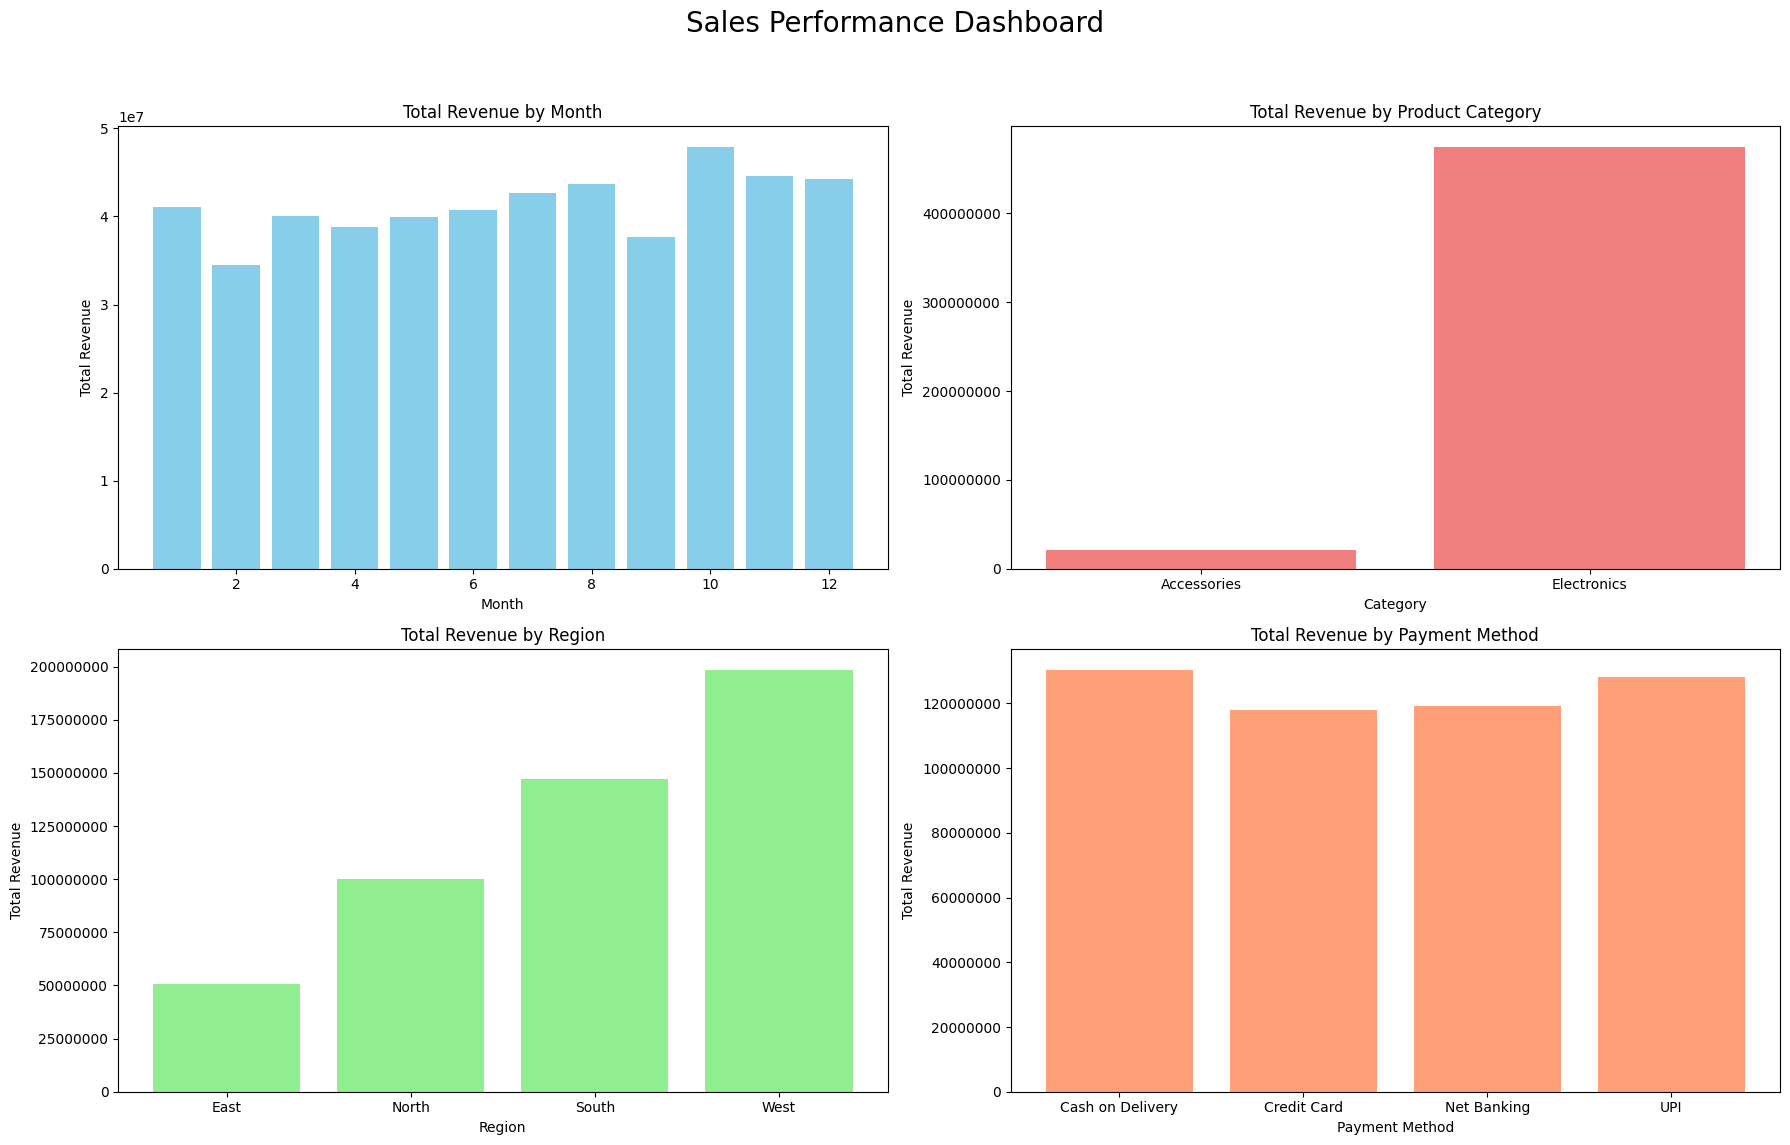

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year,month,to_date,col

# Function to safely get or create SparkSession
def get_spark_session():
    try:
        return spark
    except NameError:
        print("SparkSession 'spark' not found. Creating a new one.")
        return SparkSession.builder \
            .appName('DashboardLoader') \
            .getOrCreate()

# Ensure SparkSession is available for potential loading or creation
spark = get_spark_session()

# Check if df_sliver exists, if not, attempt to load or create
if 'df_sliver' not in locals() and 'df_sliver' not in globals():
    print("df_sliver not found in current session.")
    try:
        print("Attempting to load df_sliver from '/content/sales_sliver.parquet'.")
        df_sliver = spark.read.parquet('/content/sales_sliver.parquet')
        print("df_sliver loaded successfully from parquet.")

        # Verify or re-add year and month columns if they are not in the loaded DataFrame
        if 'month' not in df_sliver.columns and 'order_date' in df_sliver.columns:
            df_sliver = df_sliver.withColumn("order_date", to_date(col("order_date"), "yyyy-MM-dd"))
            df_sliver = df_sliver.withColumn("year", year(col("order_date"))).withColumn("month", month(col("order_date")))
        elif 'month' not in df_sliver.columns:
            print("Warning: 'month' column not found and cannot be derived from 'order_date'. Dashboard might behave unexpectedly.")

    except Exception as e: # Catch broader exception for file loading errors
        print(f"Failed to load df_sliver from parquet: {e}")
        print("Attempting to recreate df_sliver from source CSV.")

        # Recreate df_bronze if needed
        if 'df_bronze' not in locals() and 'df_bronze' not in globals():
            print("df_bronze not found. Loading from '/content/large sales dataset.csv'.")
            df_bronze = spark.read.csv('/content/large sales dataset.csv', header=True, inferSchema=True)
            # Add calculated_quantity if it's missing, as it's part of df_bronze in the notebook
            if 'calculated_quantity' not in df_bronze.columns:
                df_bronze = df_bronze.withColumn("calculated_quantity", col("revenue") / col("unit_price"))
            print("df_bronze recreated successfully.")
        else:
            print("df_bronze found in session, proceeding with df_sliver creation.")

        # Recreate df_sliver from df_bronze
        df_sliver = df_bronze \
            .dropDuplicates() \
            .dropna(subset=['quantity','unit_price','revenue'])
        df_sliver = df_sliver.withColumn("order_date",to_date(col("order_date"),"yyyy-MM-dd")) \
            .withColumn("year",year(col("order_date"))) \
            .withColumn("month",month(col("order_date")))
        df_sliver = df_sliver.withColumn("revenue_category",F.when(col('revenue')>40000,'High')\
                                                .when((col('revenue')>10000) & (col('revenue')<=40000),'Medium')\
                                                .otherwise('Low'))
        print("df_sliver recreated from df_bronze.")

# Convert Spark DataFrame to Pandas DataFrame for easier plotting with matplotlib
pd_df_sliver = df_sliver.toPandas()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Sales Performance Dashboard', fontsize=20)

# Chart 1: Total Revenue by Month
monthly_revenue = pd_df_sliver.groupby('month')['revenue'].sum().reset_index()
axes[0, 0].bar(monthly_revenue['month'], monthly_revenue['revenue'], color='skyblue')
axes[0, 0].set_title('Total Revenue by Month')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Total Revenue')

# Chart 2: Total Revenue by Category
category_revenue = pd_df_sliver.groupby('category')['revenue'].sum().reset_index()
axes[0, 1].bar(category_revenue['category'], category_revenue['revenue'], color='lightcoral')
axes[0, 1].set_title('Total Revenue by Product Category')
axes[0, 1].set_xlabel('Category')
axes[0, 1].set_ylabel('Total Revenue')
axes[0, 1].ticklabel_format(style='plain', axis='y') # Disable scientific notation

# Chart 3: Total Revenue by Region
region_revenue = pd_df_sliver.groupby('region')['revenue'].sum().reset_index()
axes[1, 0].bar(region_revenue['region'], region_revenue['revenue'], color='lightgreen')
axes[1, 0].set_title('Total Revenue by Region')
axes[1, 0].set_xlabel('Region')
axes[1, 0].set_ylabel('Total Revenue')
axes[1, 0].ticklabel_format(style='plain', axis='y') # Disable scientific notation

# Chart 4: Total Revenue by Payment Method
payment_revenue = pd_df_sliver.groupby('payment_method')['revenue'].sum().reset_index()
axes[1, 1].bar(payment_revenue['payment_method'], payment_revenue['revenue'], color='lightsalmon')
axes[1, 1].set_title('Total Revenue by Payment Method')
axes[1, 1].set_xlabel('Payment Method')
axes[1, 1].set_ylabel('Total Revenue')
axes[1, 1].ticklabel_format(style='plain', axis='y') # Disable scientific notation

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()